In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score,mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Datasets/Combined.xlsx")

df['dateTime']= pd.to_datetime(df['dateTime'])
df.set_index('dateTime', inplace=True)
# df.groupby(['activePowerT', pd.Grouper(freq='D')]).mean()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7822 entries, 2024-01-16 00:00:00 to 2024-12-07 00:00:00
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   importActiveEnergyT  7822 non-null   float64
 1   currentA             7822 non-null   float64
 2   currentB             7822 non-null   float64
 3   currentC             7822 non-null   float64
 4   voltageA             7822 non-null   float64
 5   voltageB             7822 non-null   float64
 6   voltageC             7822 non-null   float64
 7   activePowerT         7822 non-null   float64
 8   activePowerA         7822 non-null   float64
 9   activePowerB         7822 non-null   float64
 10  activePowerC         7822 non-null   float64
 11  voltageL12           7318 non-null   float64
 12  voltageL23           7318 non-null   float64
 13  voltageL31           7318 non-null   float64
dtypes: float64(14)
memory usage: 916.6 KB


## Correlation Analysis

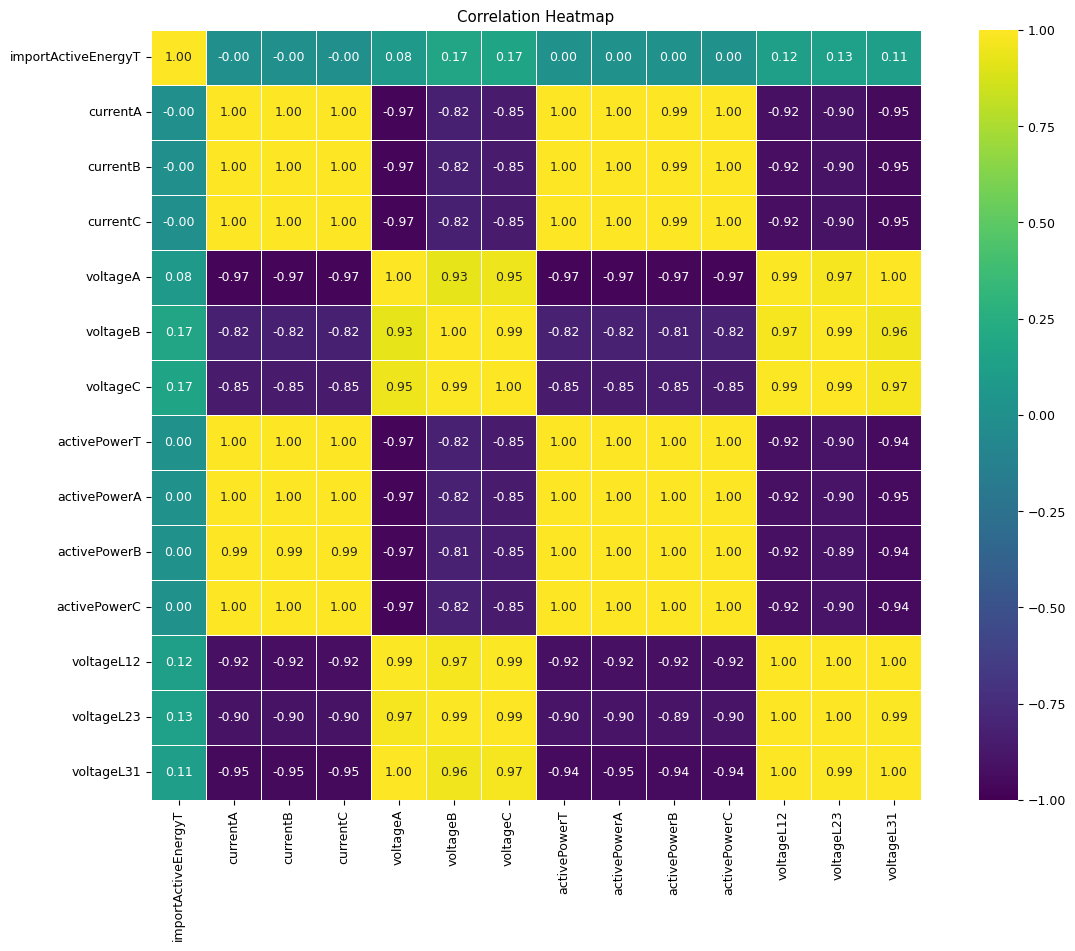

In [ ]:
# Calculate the correlation matrix
df.dropna(inplace=True)
correlation_matrix = df.corr()
plt.figure(figsize = (15,10))
plt.rcParams.update({'font.size': 9})
img = sns.heatmap(correlation_matrix, cmap = 'viridis', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5)
img.set_title('Correlation Heatmap')
plt.show()

fig = img.get_figure()
fig.savefig('/content/drive/MyDrive/Images/Feature Selection Engineering/Correlation Map')

It can be observed that single phase current & active power are highly correlated to total active power.

In [ ]:


def create_features(df, label=None):

    df=df.copy()
    # Create Lag Features
    target_mapP = df['activePowerT'].to_dict()
    target_mapA = df['currentA'].to_dict()
    target_mapAA = df['activePowerA'].to_dict()

    df['activePowerA_lag1']=(df.index-pd.Timedelta('1 days')).map(target_mapAA)
    df['currentA_lag1']=(df.index-pd.Timedelta('1 days')).map(target_mapA)

    df['lag1'] = (df.index-pd.Timedelta('1 days')).map(target_mapP)
    df['lag2'] = (df.index-pd.Timedelta('2 days')).map(target_mapP)
    df['lag3'] = (df.index-pd.Timedelta('3 days')).map(target_mapP)
    df['lag4'] = (df.index-pd.Timedelta('4 days')).map(target_mapP)
    df['lag5'] = (df.index-pd.Timedelta('5 days')).map(target_mapP)
    df['lag7'] = (df.index-pd.Timedelta('7 days')).map(target_mapP)


    # Create TIme Series features from datetime index
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df= create_features(df)
df.tail()

,importActiveEnergyT,currentA,currentB,currentC,voltageA,voltageB,voltageC,activePowerT,activePowerA,activePowerB,...,lag4,lag5,lag7,hour,dayofweek,quarter,month,dayofyear,dayofmonth,weekofyear
dateTime,,,,,,,,,,,,,,,,,,,,,
2024-12-06 20:00:00,4211967.5,630.3155,719.8280,703.2500,234.10,242.60,244.90,341.412,103.2430,128.2345,...,324.3340,5.0555,253.573,20,4,4,12,341,6,49
2024-12-06 21:00:00,4212306.0,635.2205,723.9800,706.2625,235.10,243.55,245.95,342.250,103.6075,128.6910,...,316.9055,5.0730,216.161,21,4,4,12,341,6,49
2024-12-06 22:00:00,4212625.0,615.7670,698.5580,687.2140,232.85,241.20,243.35,337.307,101.7735,125.9315,...,288.4260,5.1055,200.112,22,4,4,12,341,6,49
2024-12-06 23:00:00,4212729.5,6.3655,7.9565,13.6390,245.90,244.70,246.45,6.542,1.4045,1.8755,...,5.8220,5.8635,5.840,23,4,4,12,341,6,49
2024-12-07 00:00:00,4212735.0,6.4030,7.9630,6.9380,245.90,244.90,246.80,4.859,1.4070,1.8790,...,5.5720,4.8805,4.879,0,5,4,12,342,7,49


## Feature Importance Analysis

[0]	validation_0-mae:198.08055	validation_1-mae:219.12286
[999]	validation_0-mae:0.77172	validation_1-mae:0.92449
[0]	validation_0-mae:199.16017	validation_1-mae:222.71159
[999]	validation_0-mae:0.81719	validation_1-mae:0.73992
[0]	validation_0-mae:200.23223	validation_1-mae:197.87415
[999]	validation_0-mae:0.80194	validation_1-mae:0.57047
[0]	validation_0-mae:200.16039	validation_1-mae:208.72012
[999]	validation_0-mae:0.79861	validation_1-mae:0.69217
[0]	validation_0-mae:200.50837	validation_1-mae:197.45673
[999]	validation_0-mae:0.82699	validation_1-mae:1.08745


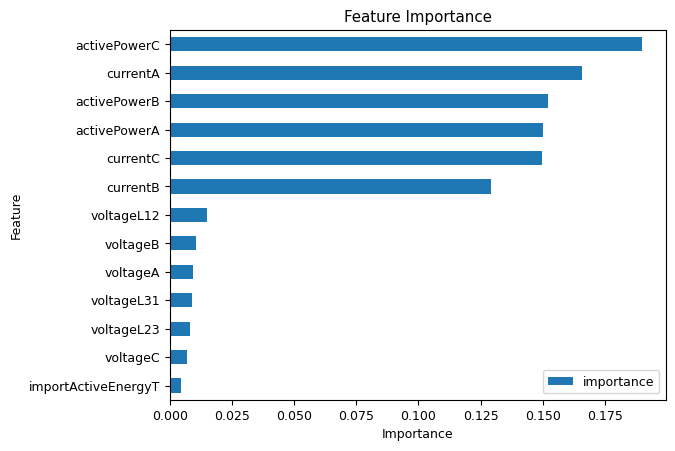

<Figure size 1500x1000 with 0 Axes>

In [ ]:
tss = TimeSeriesSplit(n_splits=5, test_size=48*7*1, gap=48)
df = df.sort_index()
fold = 0
val0 = []
val1= []
epochs=[]
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train = create_features(train)
    test = create_features(test)

    FEATURES = ['currentA','currentB','currentC','voltageA','voltageB','voltageC','activePowerA','activePowerB','activePowerC','importActiveEnergyT','voltageL12','voltageL23','voltageL31']
    TARGET = 'activePowerT'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    reg= xgb.XGBRegressor(
                          booster='gbtree',
                          n_estimators=1000,
                          early_stopping_rounds=100,
                          learning_rate=0.01,
                          objective='reg:absoluteerror',
                          max_depth=5,
                          gamma=0.8,
                          reg_alpha=0.5,
                          reg_lambda=1.0,
                          min_child_weight=3,
                          subsample = 0.8,
                          colsample_bytree= 0.8)
    reg.fit(X_train,y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=1000)
    reg.evals_result()
    epochs.append(len(reg.evals_result_['validation_0']['mae']))
    val0.append(reg.evals_result_['validation_0']['mae'])
    val1.append(reg.evals_result_['validation_1']['mae'])





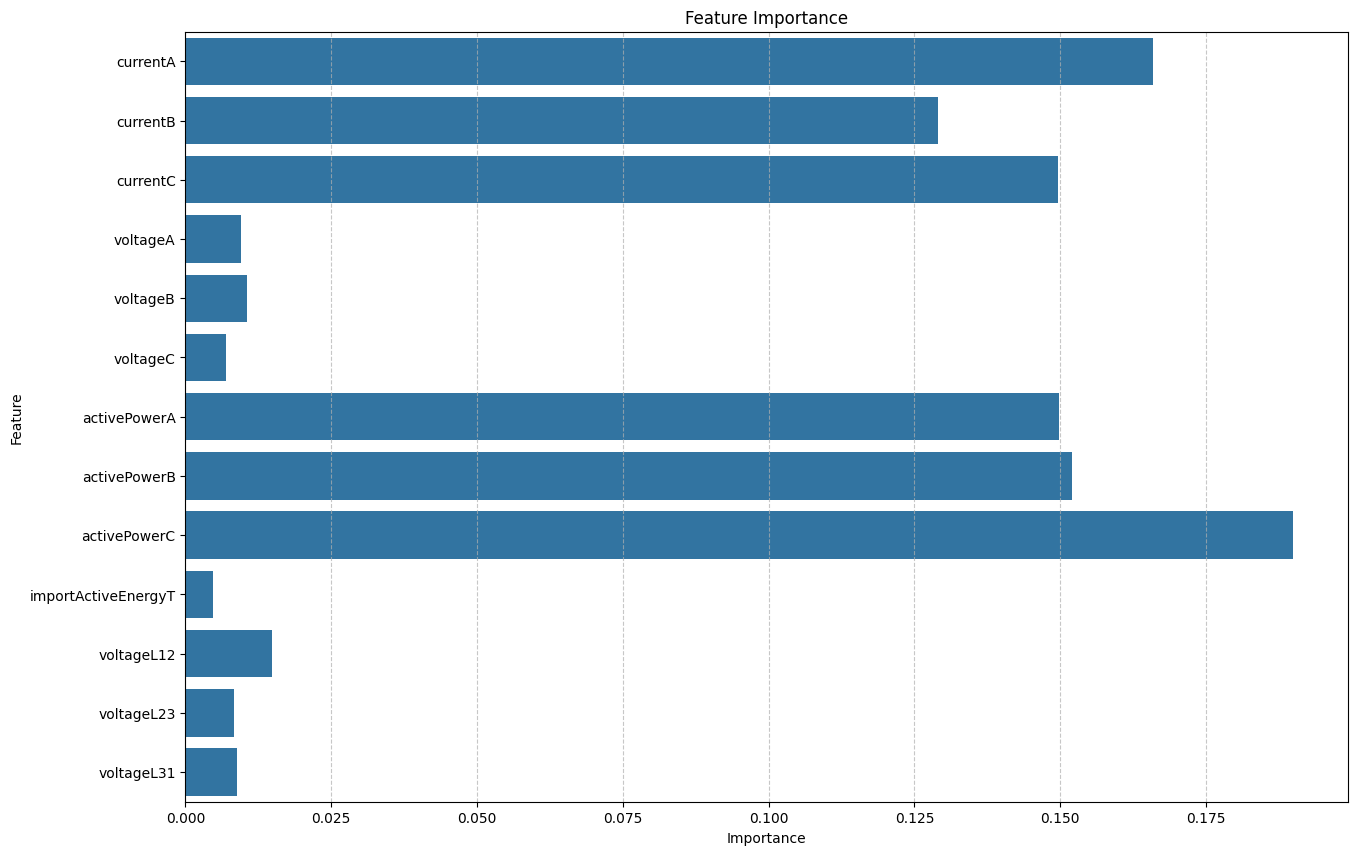

In [ ]:
fig = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
plt.figure(figsize = (15,10))
plt.rcParams.update({'font.size': 10})
img = sns.barplot(x=fig.importance, y=fig.index)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
# fig.sort_values('importance').plot(kind='barh', title='Feature Importance')


plt.show()

In [ ]:
fig = img.get_figure()
fig.savefig('/content/drive/MyDrive/Images/Feature Selection Engineering/Feature Importance')

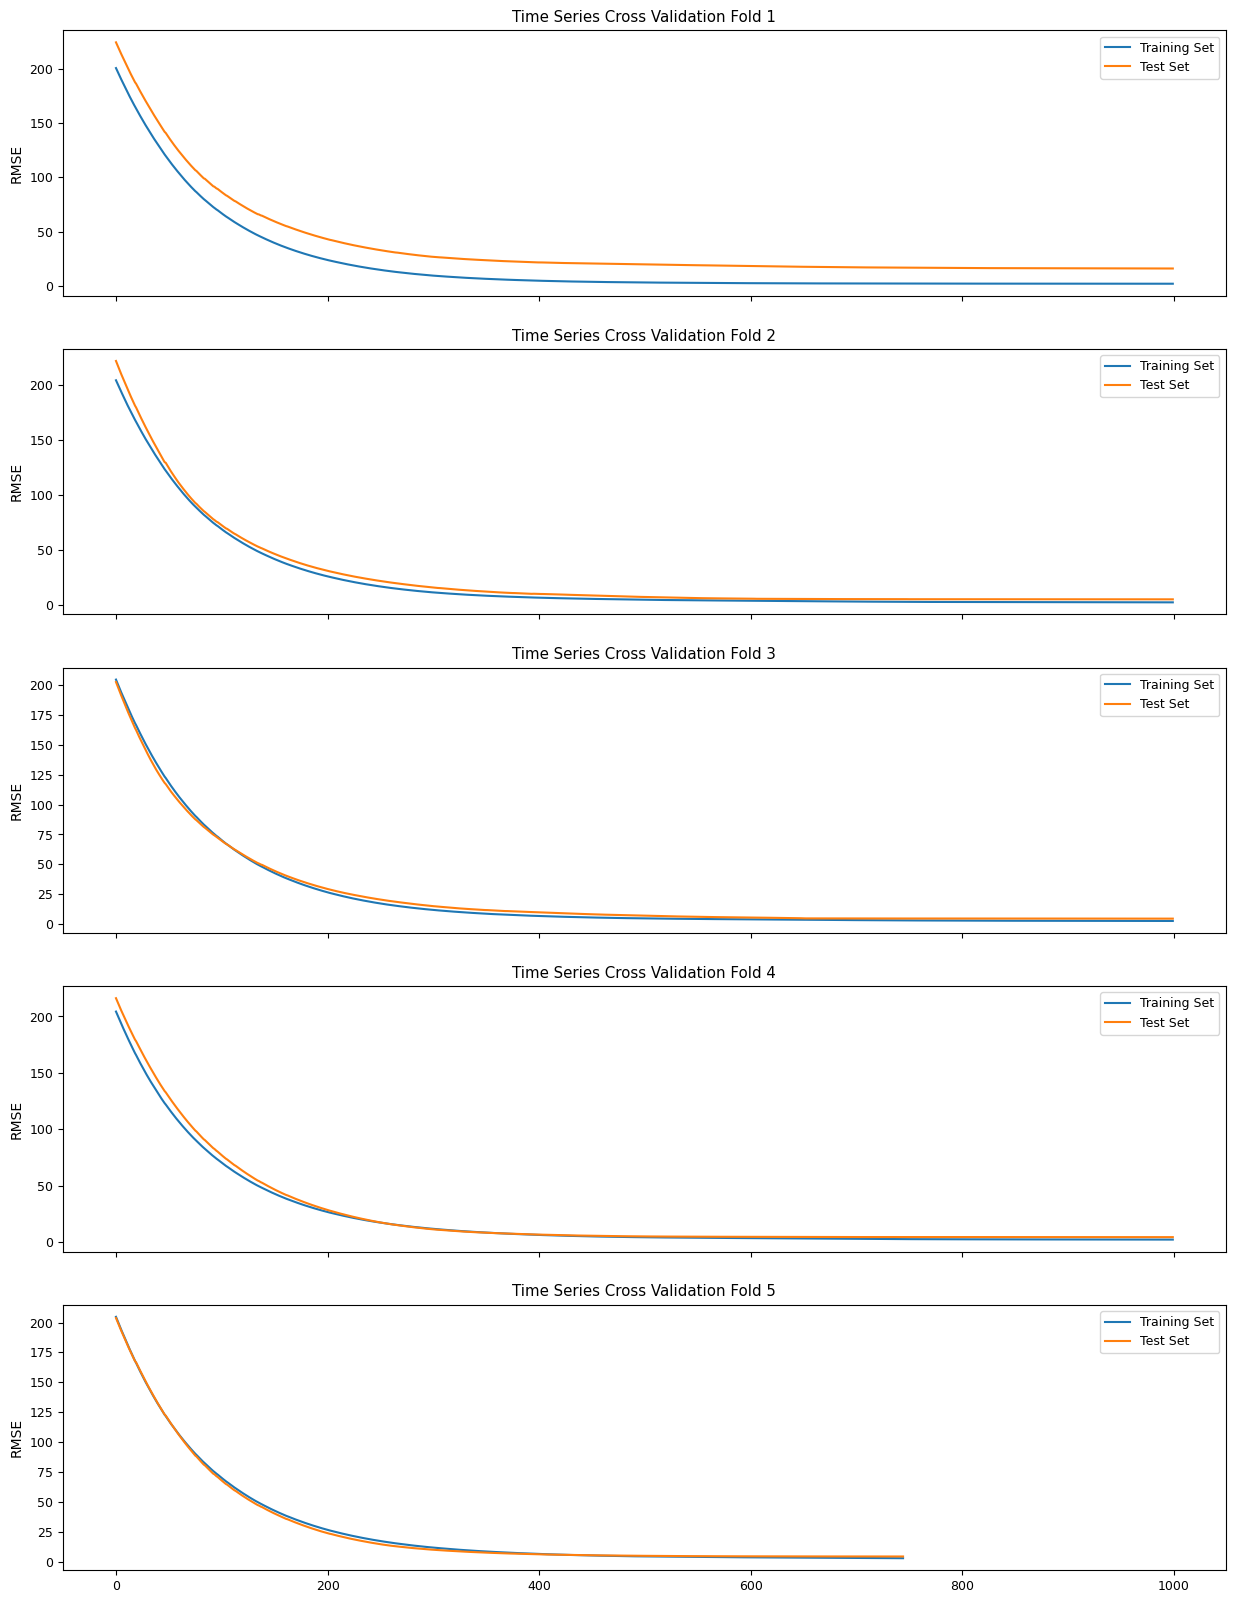

In [ ]:
fig, axs = plt.subplots(nrows=5, ncols=1, sharex=True, figsize=(15,20))
for i in range(5):
  x_axis = range(0, epochs[i])
  axs[i].plot(x_axis, val0[i], label='Train')
  axs[i].plot(x_axis, val1[i], label='Test')
  axs[i].set_title(f'Time Series Cross Validation Fold {i+1}')
  axs[i].legend()
  axs[i].legend(['Training Set', 'Test Set'])
  axs[i].set_ylabel('RMSE',fontsize=10)
